# Exploratory Data Analysis

In [72]:
import pandas as pd
import ast
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [73]:
pcl = pd.read_csv(
    DATA_DIR / "dontpatronizeme_pcl.tsv",
    sep="\t",
    header=None,
    names=["id", "par_id", "keyword", "country", "text", "category"],
)
pcl["id"] = pcl["id"].astype(int)
pcl.head(3)

,id,par_id,keyword,country,text,category
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0


In [74]:
train_labels = pd.read_csv(DATA_DIR / "train_semeval_parids-labels.csv")

def to_binary(label_str):
    vec = ast.literal_eval(label_str)
    return 1 if any(x == 1 for x in vec) else 0

train_labels["binary_label"] = train_labels["label"].apply(to_binary)
train_labels[["par_id", "binary_label"]].head(10)

,par_id,binary_label
0,4341,1
1,4136,1
2,10352,1
3,8279,1
4,1164,1
5,7568,1
6,6027,1
7,9343,1
8,1231,1
9,911,1


In [75]:

train_df = pcl[pcl["id"].isin(train_labels["par_id"])].copy()
train_df = train_df.merge(
    train_labels[["par_id", "binary_label"]],
    left_on="id",
    right_on="par_id",
    how="inner",
)
train_df = train_df[["id", "text", "binary_label"]]
print(f"Training examples: {len(train_df)}")
train_df.head()

Training examples: 8375


,id,text,binary_label
0,1,"We 're living in times of absolute insanity , ...",0
1,2,"In Libya today , there are countless number of...",0
2,3,White House press secretary Sean Spicer said t...,0
3,4,Council customers only signs would be displaye...,0
4,5,""" Just like we received migrants fleeing El Sa...",0


## EDA Technique 1: Class distribution

We analyse the balance of PCL (1) vs No PCL (0) in the training set. Imbalance matters because the task is evaluated with F1 score of the positive class (PCL), not accuracy.

In [76]:
counts = train_df["binary_label"].value_counts().sort_index()
pcts = train_df["binary_label"].value_counts(normalize=True).sort_index() * 100
print(counts)
print(pcts)
imbalance_ratio = counts.get(0, 0) / counts.get(1, 0)
print(f"Class imbalance ratio (No PCL : PCL) = {imbalance_ratio:.2f}")

class_names = ["No PCL (0)", "PCL (1)"]
dist_table = pd.DataFrame({
    "Class": class_names,
    "Count": [counts.get(0, 0), counts.get(1, 0)],
    "Percentage (%)": [round(pcts.get(0, 0), 1), round(pcts.get(1, 0), 1)],
})
dist_table

binary_label
0    7581
1     794
Name: count, dtype: int64
binary_label
0    90.519403
1     9.480597
Name: proportion, dtype: float64
Class imbalance ratio (No PCL : PCL) = 9.55


,Class,Count,Percentage (%)
0,No PCL (0),7581,90.5
1,PCL (1),794,9.5


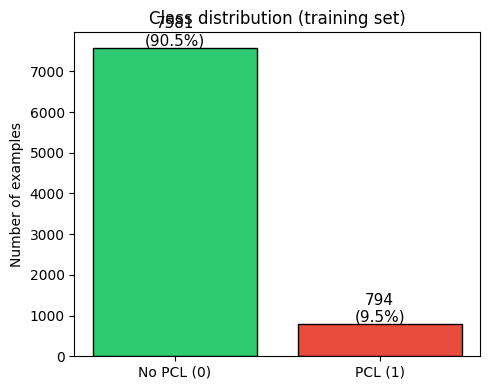

In [77]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(class_names, [counts.get(0, 0), counts.get(1, 0)], color=["#2ecc71", "#e74c3c"], edgecolor="black")
ax.set_ylabel("Number of examples")
ax.set_title("Class distribution (training set)")
for i, (c, p) in enumerate(zip([counts.get(0, 0), counts.get(1, 0)], [pcts.get(0, 0), pcts.get(1, 0)])):
    ax.text(i, c + 50, f"{c}\n({p:.1f}%)", ha="center", fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Analysis:** The training set is imbalanced: the majority class (No PCL) has many more examples than the positive class (PCL). A classifier that always predicts the majority class would achieve high accuracy but zero F1 on the positive class.

Because the coursework evaluates positive-class F1, this imbalance motivates using class weighting (e.g. in the loss), resampling (oversampling PCL or undersampling No PCL), or threshold tuning at prediction time, rather than relying on raw accuracy or default decision thresholds. This suggests that accuracy is not an appropriate evaluation metric and motivates the use of class weighting or threshold tuning to improve positive-class F1.

## EDA Technique 2: Text length (word count) distribution

We measure paragraph length in words to inform maximum sequence length for a transformer and the risk of truncation. We use word count rather than token count as word count is a close proxy and avoids tokeniser dependency.

In [78]:
train_df["word_count"] = train_df["text"].apply(lambda x: len(str(x).split()))

length_stats = train_df["word_count"].describe()
p90 = int(train_df["word_count"].quantile(0.90))
p95 = int(train_df["word_count"].quantile(0.95))
p99 = int(train_df["word_count"].quantile(0.99))

summary_table = pd.DataFrame({
    "Statistic": ["Minimum", "Mean", "Median", "Maximum", "Std dev", "90th %ile", "95th %ile", "99th %ile"],
    "Words": [
        int(length_stats["min"]),
        round(length_stats["mean"], 1),
        int(length_stats["50%"]),
        int(length_stats["max"]),
        round(length_stats["std"], 1),
        p90, p95, p99,
    ],
})
summary_table

,Statistic,Words
0,Minimum,1.0
1,Mean,48.7
2,Median,42.0
3,Maximum,909.0
4,Std dev,29.7
5,90th %ile,84.0
6,95th %ile,102.0
7,99th %ile,142.0


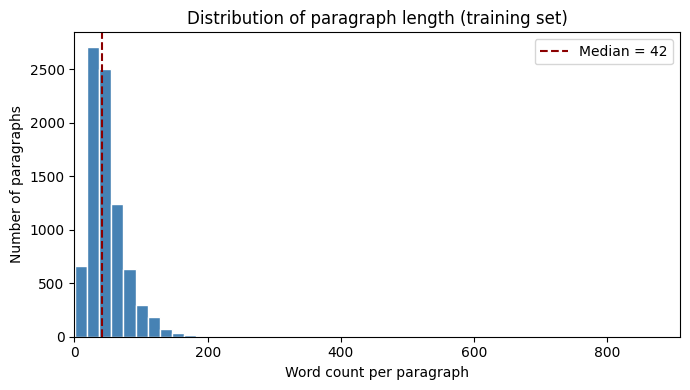

In [79]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_df["word_count"], bins=50, color="steelblue", edgecolor="white")
ax.axvline(train_df["word_count"].median(), color="darkred", linestyle="--", label=f"Median = {int(train_df['word_count'].median())}")
ax.set_xlim(0, train_df["word_count"].max())
ax.set_xlabel("Word count per paragraph")
ax.set_ylabel("Number of paragraphs")
ax.set_title("Distribution of paragraph length (training set)")
ax.legend()
plt.tight_layout()
plt.show()

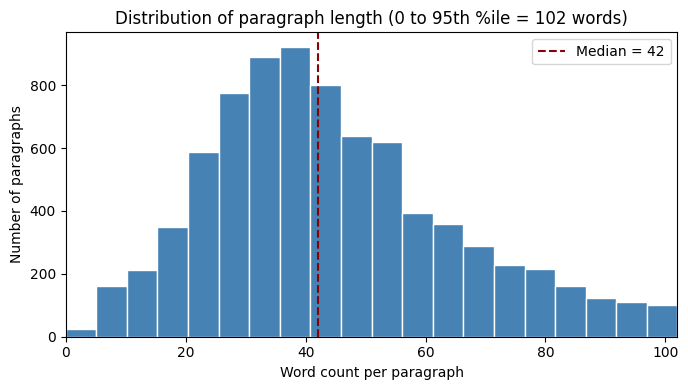

In [80]:
fig, ax = plt.subplots(figsize=(7, 4))
within_p95 = train_df["word_count"][train_df["word_count"] <= p95]
ax.hist(within_p95, bins=20, range=(0, p95), color="steelblue", edgecolor="white")
ax.axvline(train_df["word_count"].median(), color="darkred", linestyle="--", label=f"Median = {int(train_df['word_count'].median())}")
ax.set_xlim(0, p95)
ax.set_xlabel("Word count per paragraph")
ax.set_ylabel("Number of paragraphs")
ax.set_title(f"Distribution of paragraph length (0 to 95th %ile = {p95} words)")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [81]:
train_df.groupby("binary_label")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
binary_label,,,,,,,,
0,7581.0,48.167656,29.183814,1.0,30.0,42.0,59.0,909.0
1,794.0,53.521411,33.673945,6.0,33.0,47.0,66.0,512.0


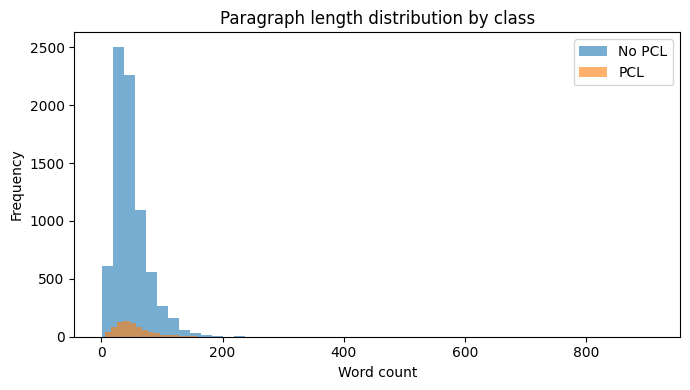

In [82]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_df[train_df["binary_label"] == 0]["word_count"], bins=50, alpha=0.6, label="No PCL")
ax.hist(train_df[train_df["binary_label"] == 1]["word_count"], bins=50, alpha=0.6, label="PCL")
ax.legend()
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.set_title("Paragraph length distribution by class")
plt.tight_layout()
fig.savefig(FIG_DIR / "length_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

**Analysis:** The histograms are strongly right-skewed. Most paragraphs are short: the median is 42 words and the peak (mode) is in the 35–45 word range—the tallest bars sit just before and after the 40-word mark. Frequency drops off quickly as word count increases; beyond about 200 words there are very few paragraphs, and the distribution effectively ends by 300–400 words. The long tail extends to the maximum (909 words), so the full-range plot has a large empty region on the right. The second plot limits the x-axis to the 95th percentile (102 words) with equal-width bins so the main body of the distribution is visible without that empty tail.

**Impact statement:** The 90th, 95th and 99th percentiles (see table above) give the word counts below which 90%, 95% and 99% of paragraphs fall. For a transformer such as RoBERTa, token counts are typically about 1.2–1.4× word count for English, so the 95th percentile in words corresponds to roughly 1.3× that value in tokens. With the observed percentiles, max_length=128 would truncate a large share of paragraphs (e.g. everything above the 90th percentile in words). We recommend max_length=256 so that at least 95% of training paragraphs fit without truncation; the small fraction of very long paragraphs (e.g. above the 99th percentile) can be truncated or handled separately without materially affecting overall performance. The distribution suggests that a maximum sequence length around 256 tokens should capture most paragraphs while limiting unnecessary padding.